# Laplacian Eigenmaps on OGB Downstream Tasks

This notebook tests **Laplacian Eigenmaps graph encodings** on OGB graph property prediction datasets.

Downstream task: binary graph classification using logistic regression on spectral features.

In [1]:
import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix, diags, eye
from scipy.sparse.linalg import eigsh

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# OGB currently expects torch.load(weights_only=False) for cached metadata in many datasets.
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

from ogb.graphproppred import GraphPropPredDataset

np.random.seed(7)

In [2]:
def laplacian_eigenmaps_graph_embedding(graph, n_components=8):
    """Encode one graph into a fixed-size feature vector using Laplacian Eigenmaps."""
    num_nodes = int(graph["num_nodes"])
    feature_dim = 3 * n_components

    if num_nodes < 2:
        return np.zeros(feature_dim, dtype=np.float32)

    edge_index = graph["edge_index"]
    row = edge_index[0].astype(np.int64)
    col = edge_index[1].astype(np.int64)
    data = np.ones(row.shape[0], dtype=np.float64)

    A = coo_matrix((data, (row, col)), shape=(num_nodes, num_nodes)).tocsr()
    A = A + A.T
    A.data[:] = 1.0
    A.eliminate_zeros()

    degrees = np.asarray(A.sum(axis=1)).ravel()
    inv_sqrt_deg = np.zeros_like(degrees)
    nonzero = degrees > 0
    inv_sqrt_deg[nonzero] = 1.0 / np.sqrt(degrees[nonzero])

    D_inv_sqrt = diags(inv_sqrt_deg)
    L = eye(num_nodes, format="csr") - D_inv_sqrt @ A @ D_inv_sqrt

    k = min(n_components + 1, num_nodes - 1)
    if k <= 0:
        return np.zeros(feature_dim, dtype=np.float32)

    try:
        eigvals, eigvecs = eigsh(L, k=k, which="SM")
    except Exception:
        dense_L = L.toarray()
        eigvals_full, eigvecs_full = np.linalg.eigh(dense_L)
        eigvals = eigvals_full[:k]
        eigvecs = eigvecs_full[:, :k]

    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    keep = eigvals > 1e-8
    eigvals = eigvals[keep][:n_components]
    eigvecs = eigvecs[:, keep][:, :n_components]

    eigvals_padded = np.zeros(n_components, dtype=np.float32)
    eigvals_padded[: len(eigvals)] = eigvals

    if eigvecs.shape[1] == 0:
        coord_means = np.zeros(n_components, dtype=np.float32)
        coord_stds = np.zeros(n_components, dtype=np.float32)
    else:
        abs_coords = np.abs(eigvecs)
        coord_means = np.zeros(n_components, dtype=np.float32)
        coord_stds = np.zeros(n_components, dtype=np.float32)
        coord_means[: abs_coords.shape[1]] = abs_coords.mean(axis=0)
        coord_stds[: abs_coords.shape[1]] = abs_coords.std(axis=0)

    return np.concatenate([eigvals_padded, coord_means, coord_stds]).astype(np.float32)

In [3]:
def resolve_ogb_root(root=None):
    if root is not None:
        p = Path(root)
        p.mkdir(parents=True, exist_ok=True)
        return p

    candidates = [
        Path("ogb_data"),
        Path("Laplacian_Eigenmaps") / "ogb_data",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    candidates[0].mkdir(parents=True, exist_ok=True)
    return candidates[0]


def build_dataset_features(dataset_name, root=None, n_components=8):
    root_path = resolve_ogb_root(root)
    dataset = GraphPropPredDataset(name=dataset_name, root=str(root_path))
    split_idx = dataset.get_idx_split()

    X = np.zeros((len(dataset), 3 * n_components), dtype=np.float32)
    y = np.zeros(len(dataset), dtype=np.float32)

    for i in range(len(dataset)):
        graph, label = dataset[i]
        X[i] = laplacian_eigenmaps_graph_embedding(graph, n_components=n_components)
        y[i] = float(label[0])

    return dataset, split_idx, X, y


def _binary_labeled_indices(indices, y):
    indices = np.asarray(indices, dtype=np.int64)
    values = y[indices]
    valid = np.isfinite(values) & ((values == 0.0) | (values == 1.0))
    return indices[valid]


def evaluate_graph_classification(X, y, split_idx):
    train_idx = _binary_labeled_indices(split_idx["train"], y)
    valid_idx = _binary_labeled_indices(split_idx["valid"], y)
    test_idx = _binary_labeled_indices(split_idx["test"], y)

    y_train = y[train_idx].astype(int)
    y_valid = y[valid_idx].astype(int)
    y_test = y[test_idx].astype(int)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Training split has fewer than two classes.")

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2500, class_weight="balanced", random_state=7),
    )
    clf.fit(X[train_idx], y_train)

    valid_prob = clf.predict_proba(X[valid_idx])[:, 1]
    test_prob = clf.predict_proba(X[test_idx])[:, 1]

    valid_pred = (valid_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    return {
        "train_size": int(len(train_idx)),
        "valid_size": int(len(valid_idx)),
        "test_size": int(len(test_idx)),
        "valid_rocauc": float(roc_auc_score(y_valid, valid_prob)),
        "test_rocauc": float(roc_auc_score(y_test, test_prob)),
        "valid_accuracy": float(accuracy_score(y_valid, valid_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
    }

In [4]:
dataset_names = ["ogbg-molbace", "ogbg-molbbbp"]
results = []

for name in dataset_names:
    start = time.time()
    dataset, split_idx, X, y = build_dataset_features(name, n_components=8)
    metrics = evaluate_graph_classification(X, y, split_idx)
    metrics["dataset"] = name
    metrics["num_graphs"] = int(len(dataset))
    metrics["feature_dim"] = int(X.shape[1])
    metrics["elapsed_sec"] = round(time.time() - start, 2)
    results.append(metrics)

results_df = pd.DataFrame(results)[
    [
        "dataset",
        "num_graphs",
        "feature_dim",
        "train_size",
        "valid_size",
        "test_size",
        "valid_rocauc",
        "test_rocauc",
        "valid_accuracy",
        "test_accuracy",
        "elapsed_sec",
    ]
]
results_df = results_df.sort_values("test_rocauc", ascending=False).reset_index(drop=True)
results_df

/Users/abhi/ml/290Final/.conda-env/lib/python3.11/site-packages/ogb/graphproppred/dataset.py:67: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  loaded_dict = torch.load(pre_processed_file_path, 'rb')


/Users/abhi/ml/290Final/.conda-env/lib/python3.11/site-packages/ogb/graphproppred/dataset.py:67: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  loaded_dict = torch.load(pre_processed_file_path, 'rb')


,dataset,num_graphs,feature_dim,train_size,valid_size,test_size,valid_rocauc,test_rocauc,valid_accuracy,test_accuracy,elapsed_sec
0,ogbg-molbace,1513,24,1210,151,152,0.657509,0.760563,0.629139,0.710526,3.44
1,ogbg-molbbbp,2039,24,1631,204,204,0.810116,0.638841,0.740196,0.607843,3.14


In [5]:
for _, row in results_df.iterrows():
    print(
        f"{row['dataset']}: test ROC-AUC={row['test_rocauc']:.4f}, "
        f"test Acc={row['test_accuracy']:.4f}, time={row['elapsed_sec']}s"
    )

ogbg-molbace: test ROC-AUC=0.7606, test Acc=0.7105, time=3.44s
ogbg-molbbbp: test ROC-AUC=0.6388, test Acc=0.6078, time=3.14s


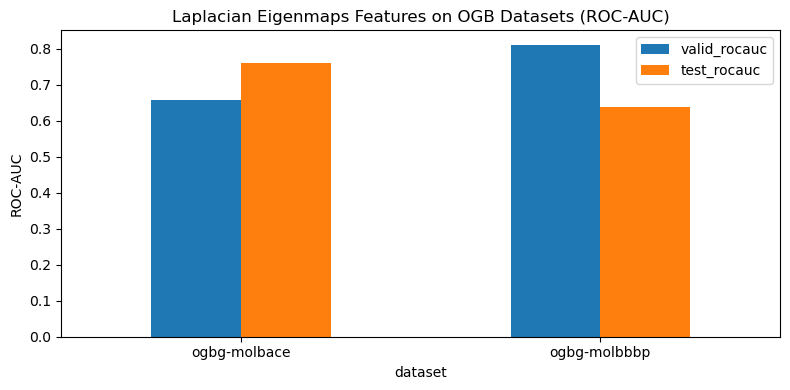

In [6]:
ax = results_df.plot(
    x="dataset",
    y=["valid_rocauc", "test_rocauc"],
    kind="bar",
    figsize=(8, 4),
    rot=0,
    title="Laplacian Eigenmaps Features on OGB Datasets (ROC-AUC)",
)
ax.set_ylabel("ROC-AUC")
plt.tight_layout()
plt.show()